In [2]:
import numpy as np
import pandas as pd

titanic=pd.read_csv('Titanic-Dataset.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df=titanic[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]

In [10]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [14]:
# titanic=titanic.fillna(titanic.mean(numeric_only=True))

df['Age']=df['Age'].fillna(df['Age'].mean())

In [16]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [18]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [20]:
df['Sex']=df['Sex'].map({'male':0,'female':1})

In [22]:
# titanic['embarked_num'] = titanic['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

df_final = pd.get_dummies(df, columns=['Embarked'],drop_first=True,dtype=int)

In [24]:
df_final.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


In [26]:
X=df_final.drop(['Survived'],axis=1)
y=df_final['Survived']

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

model=LogisticRegression()
model.fit(X_train_scaled,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred=model.predict(X_test_scaled)

In [34]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)

In [36]:
accuracy

0.8100558659217877

In [46]:
from sklearn.metrics import confusion_matrix,classification_report
cf_mtr=confusion_matrix(y_test,y_pred)
clf_rp=classification_report(y_test,y_pred)

In [48]:
print('confusion matrix',cf_mtr)

confusion matrix [[92 13]
 [21 53]]


In [52]:
print('classification report' , clf_rp)

classification report               precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



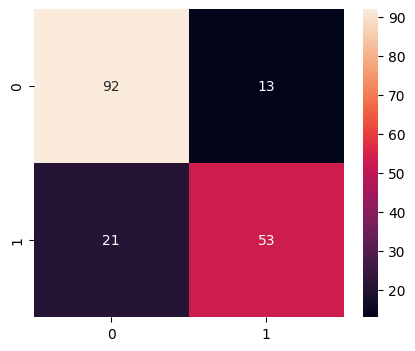

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cf_mtr,annot=True)
plt.show()

In [62]:
import pandas as pd

# Check which features the model liked most
importance = pd.DataFrame(model.coef_[0], X.columns, columns=['Weight'])
print(importance.sort_values(by='Weight', ascending=False))

              Weight
Sex         1.276292
Fare        0.124708
Embarked_Q -0.039594
Parch      -0.099004
Embarked_S -0.192275
SibSp      -0.351385
Age        -0.405537
Pclass     -0.788321


# Combining all classification models

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [68]:
models={
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100,max_depth=5),
    'KNN': KNeighborsClassifier(),
    'Support Vector Classifier': SVC()
}

In [70]:
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    prediction=model.predict(X_test_scaled)
    accuracy=accuracy_score(y_test,prediction)
    print(f'Accuracy\n{name}:{accuracy}')
    print(f'training score{model.score(X_train_scaled,y_train)}\ntesting score{model.score(X_test_scaled,y_test)}\n')
    

Accuracy
Logistic Regression:0.8100558659217877
training score0.8019662921348315
testing score0.8100558659217877

Accuracy
Decision Tree:0.7988826815642458
training score0.8497191011235955
testing score0.7988826815642458

Accuracy
Random Forest:0.8100558659217877
training score0.8553370786516854
testing score0.8100558659217877

Accuracy
KNN:0.8212290502793296
training score0.8693820224719101
testing score0.8212290502793296

Accuracy
Support Vector Classifier:0.8156424581005587
training score0.8469101123595506
testing score0.8156424581005587

